In [1]:
import os

print(os.listdir('/kaggle/input/datasets/suprithamathi'))

['brain-tumor']


In [2]:
print(os.listdir('/kaggle/input/datasets/suprithamathi/brain-tumor'))

['Training', 'Testing']


In [3]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNet

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

2026-05-16 04:48:02.307638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778906882.508597      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778906882.560764      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778906882.971886      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778906882.971926      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778906882.971928      57 computation_placer.cc:177] computation placer alr

In [4]:
train_path = "/kaggle/input/datasets/suprithamathi/brain-tumor/Training"

test_path = "/kaggle/input/datasets/suprithamathi/brain-tumor/Testing"

# Image preprocessing with validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Test data generator (completely separate)
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

# Testing generator
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [5]:
# Load pretrained MobileNet model
base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build model
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.5),

    Dense(4, activation='softmax')

])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

I0000 00:00:1778906907.827353      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,232,964 (12.33 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

# Proper Dataset Separation

This notebook now follows correct machine learning methodology:

- Training set → used for learning model weights
- Validation set → used during training for monitoring performance
- Test set → kept completely separate and used only for final evaluation

This avoids data leakage and ensures unbiased evaluation results.


In [6]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=100

)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1778906956.101372     145 service.cc:152] XLA service 0x78d7c0125a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778906956.101419     145 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778906956.787916     145 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778906962.042058     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 358ms/step - accuracy: 0.2191 - loss: 2.3282 - val_accuracy: 0.3682 - val_loss: 1.4536
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.3008 - loss: 1.9448 - val_accuracy: 0.4520 - val_loss: 1.3126
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.3881 - loss: 1.6174 - val_accuracy: 0.4834 - val_loss: 1.1943
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.3918 - loss: 1.5531 - val_accuracy: 0.5340 - val_loss: 1.0939
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.4617 - loss: 1.3393 - val_accuracy: 0.5410 - val_loss: 1.0373
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.5099 - loss: 1.2075 - val_accuracy: 0.5689 - val_loss: 0.9793
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.5579 - loss: 1.0978 - val_accuracy: 0.6143 - val_loss: 0.9232
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.5959 - loss: 1.0243 - val_accuracy: 0.6353

In [7]:
# Unfreeze the last few layers of MobileNet

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100
)


Epoch 1/100


2026-05-16 05:24:34.088441: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 05:24:34.288934: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


20/72 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.5674 - loss: 1.4376

2026-05-16 05:24:41.368234: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 05:24:41.570668: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 266ms/step - accuracy: 0.6256 - loss: 1.2261 - val_accuracy: 0.8307 - val_loss: 0.4529
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.7784 - loss: 0.6795 - val_accuracy: 0.8028 - val_loss: 0.5360
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.8449 - loss: 0.4727 - val_accuracy: 0.8010 - val_loss: 0.5378
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.8467 - loss: 0.4379 - val_accuracy: 0.7923 - val_loss: 0.5562
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.8837 - loss: 0.3665 - val_accuracy: 0.8220 - val_loss: 0.4963
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.8952 - loss: 0.2884 - val_accuracy: 0.8429 - val_loss: 0.4764
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.9020 - loss: 0.2734 - val_accuracy: 0.8482 - val_loss: 0.4571
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.9069 - loss: 0.2405 - val_accuracy: 0.8569 - 

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 0.9180 - val_loss: 0.3492
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.9990 - loss: 0.0060 - val_accuracy: 0.9145 - val_loss: 0.3527
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.9996 - loss: 0.0055 - val_accuracy: 0.9180 - val_loss: 0.3411
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.9985 - loss: 0.0066 - val_accuracy: 0.9145 - val_loss: 0.3445
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.9987 - loss: 0.0065 - val_accuracy: 0.9127 - val_loss: 0.3473
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9976 - loss: 0.0097 - val_accuracy: 0.9145 - val_loss: 0.3495
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.9970 - loss: 0.0084 - val_accuracy: 0.9180 - val_loss: 0.3527
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.9995 - loss: 0.0055 - val_accu

In [9]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)

print("Test Loss:", test_loss)

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 598ms/step - accuracy: 0.5846 - loss: 4.3498
Test Accuracy: 0.7411167621612549
Test Loss: 2.1881613731384277


In [10]:
from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 304ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.29      0.45       100
meningioma_tumor       0.64      1.00      0.78       115
        no_tumor       0.74      0.98      0.84       105
 pituitary_tumor       1.00      0.61      0.76        74

        accuracy                           0.74       394
       macro avg       0.84      0.72      0.71       394
    weighted avg       0.82      0.74      0.71       394



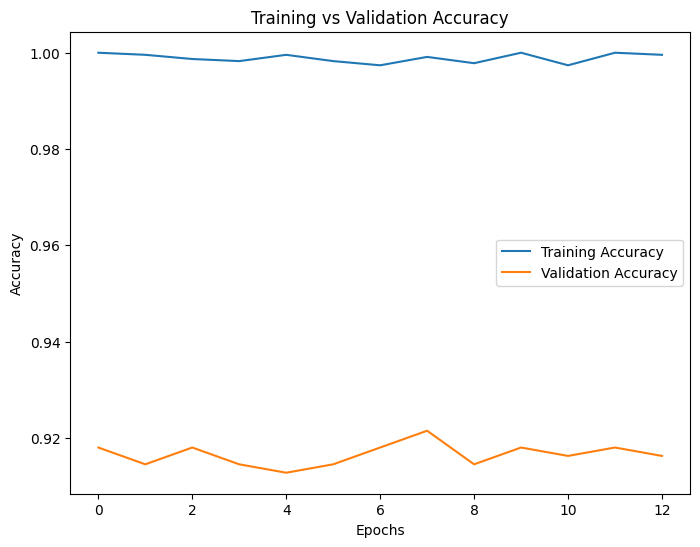

In [11]:
plt.figure(figsize=(8,6))

plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')

plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()

plt.show()

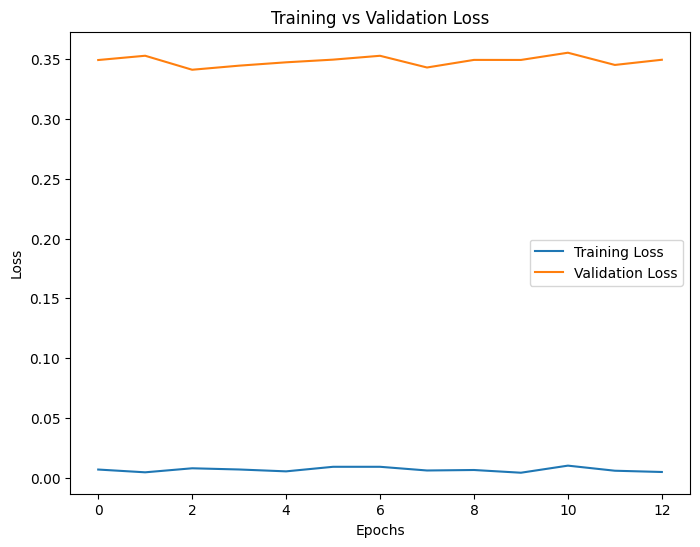

In [12]:
plt.figure(figsize=(8,6))

plt.plot(history_finetune.history['loss'], label='Training Loss')

plt.plot(history_finetune.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

# Classification report
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.29      0.45       100
meningioma_tumor       0.64      1.00      0.78       115
        no_tumor       0.74      0.98      0.84       105
 pituitary_tumor       1.00      0.61      0.76        74

        accuracy                           0.74       394
       macro avg       0.84      0.72      0.71       394
    weighted avg       0.82      0.74      0.71       394

